In [21]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [22]:
import json

# Load all results
with open("../results_llava-hf/llava-1.5-7b-hf/attention_analysis/attention_results_detailed.json", "r") as f:
    results = [json.loads(line) for line in f]


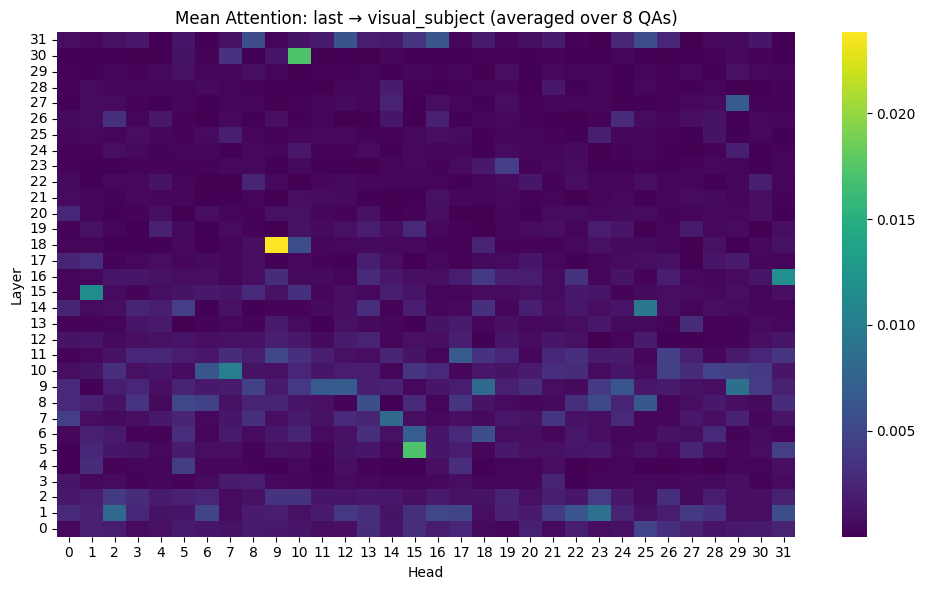

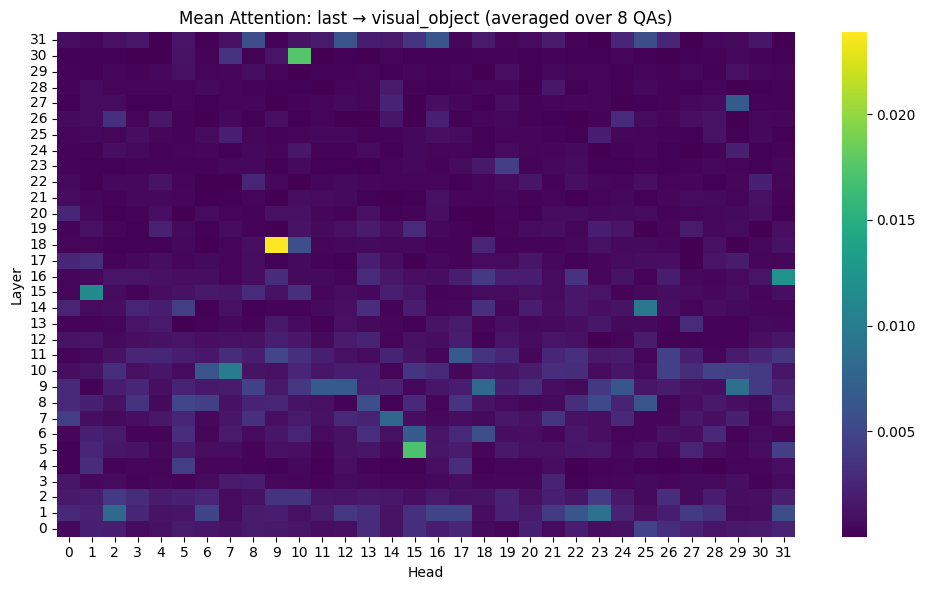

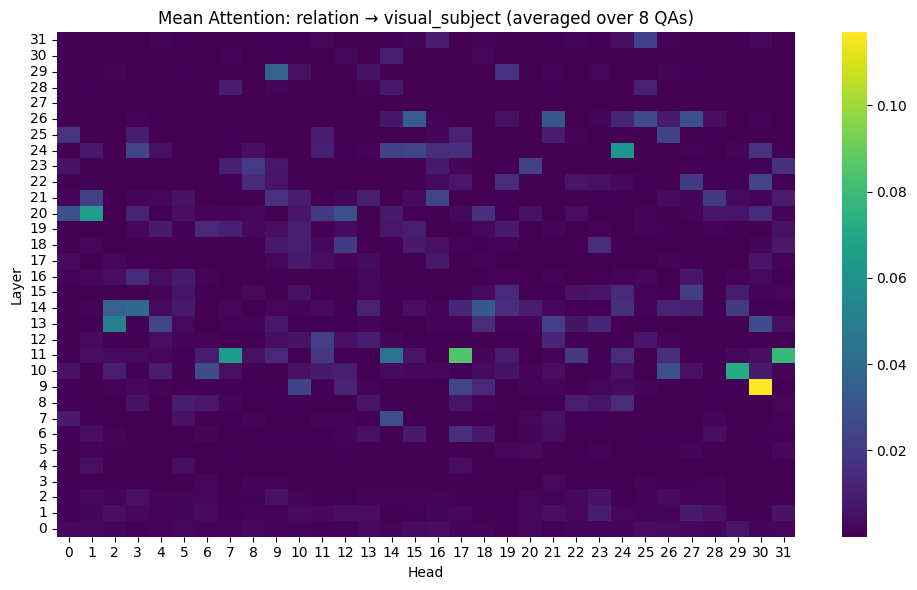

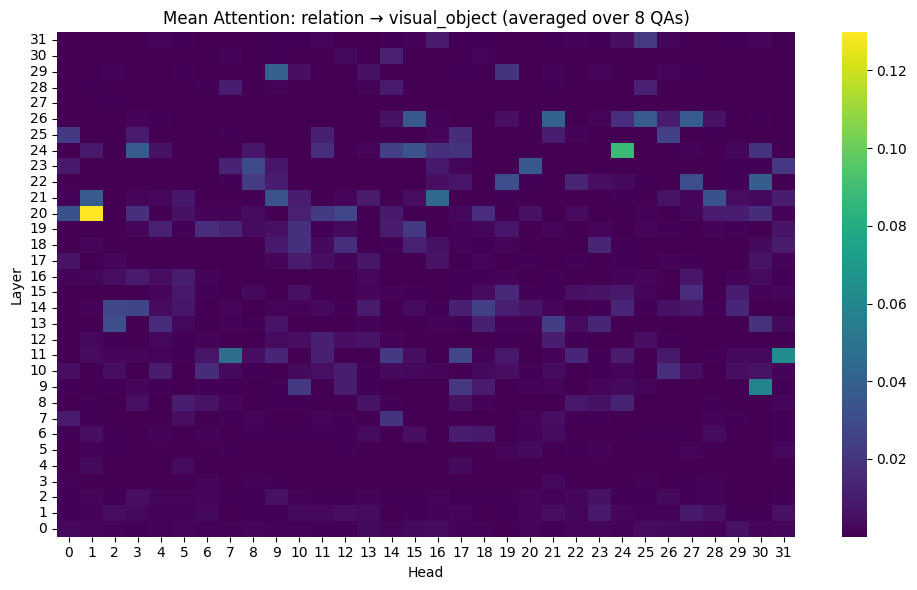

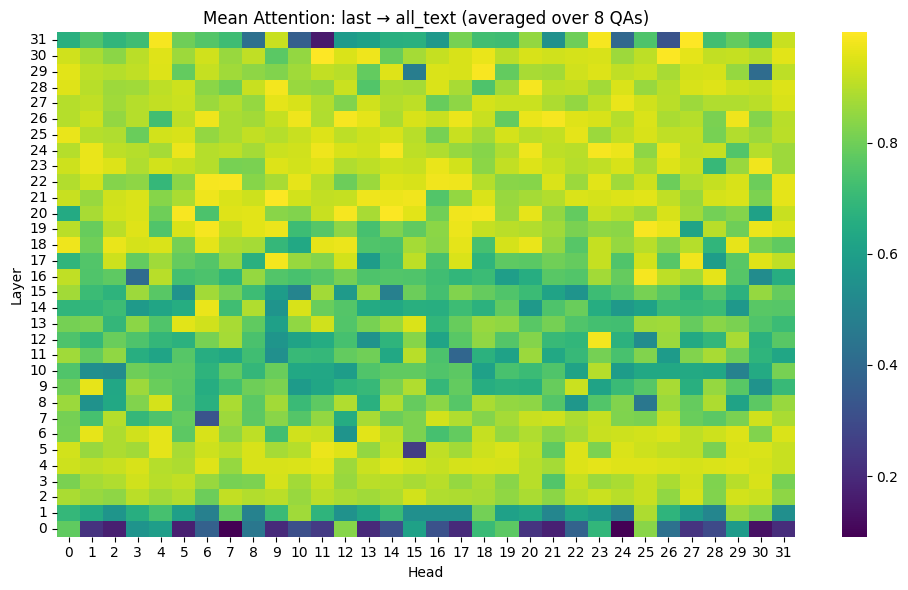

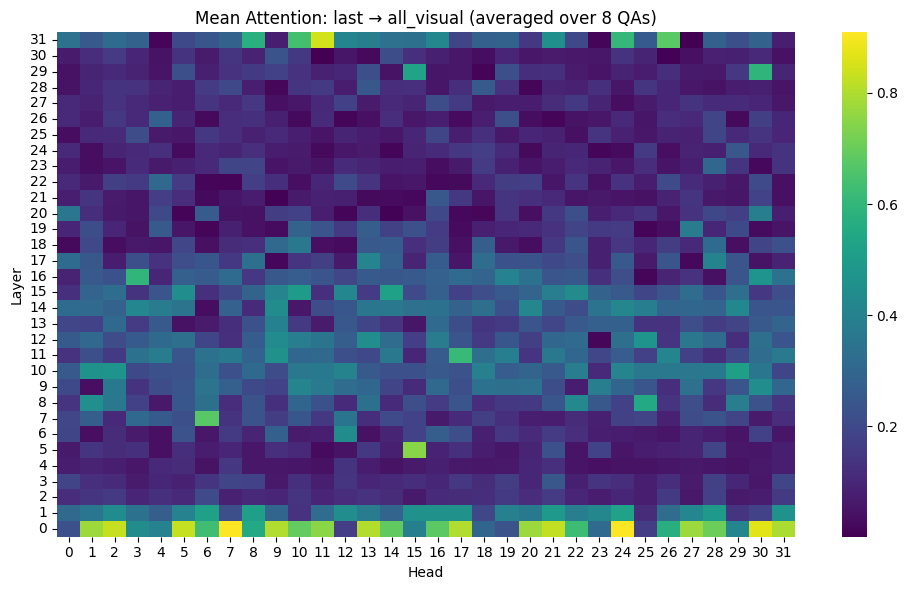

In [27]:
# Load all results (as a single JSON object)
with open("../results_llava-hf/llava-1.5-7b-hf/attention_analysis/attention_results_detailed.json", "r") as f:
    results = [json.loads(line) for line in f]

# Collect all grids for each (src, tgt) pair
pair_to_grids = {}

for result in results:
    attn_metrics = result["attention_metrics"]
    for pair in attn_metrics["group_pairs"]:
        src = pair["source_group"]
        tgt = pair["target_group"]
        per_layer = pair["per_layer"]
        attn_grid = np.array([layer["per_head_fraction"] for layer in per_layer])  # (layers, heads)
        key = (src, tgt)
        pair_to_grids.setdefault(key, []).append(attn_grid)

# Compute and plot the mean grid for each pair
for (src, tgt), grids in pair_to_grids.items():
    mean_grid = np.mean(grids, axis=0)  # mean over all QAs
    plt.figure(figsize=(10, 6))
    sns.heatmap(mean_grid, cmap="viridis", annot=False)
    plt.title(f"Mean Attention: {src} → {tgt} (averaged over {len(grids)} QAs)")
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()